<a href="https://colab.research.google.com/github/sahilshah9111/KarmixTech_CustomerChurnPrediction/blob/main/customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###1. Importing Libraries



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

###2. Importing dataset

In [2]:
dt = pd.read_csv('churn.csv')
dt.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


###3. Exploring the dataset

In [3]:
dt.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
dt.shape

(7043, 21)

In [6]:
dt.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
dt.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


###4. Data Cleaning

In [8]:
dt.drop('customerID', axis = 1, inplace = True) #not necessary columns for prediction

In [9]:
dt['TotalCharges'] = pd.to_numeric(dt['TotalCharges'], errors='coerce') # Changing 'TotalCharges' datatype from object to numeric type

In [10]:
dt['TotalCharges'] = dt['TotalCharges'].fillna(dt['TotalCharges'].median())

###5. Exploratory Data Analysis

CHURN DISTRIBUTION

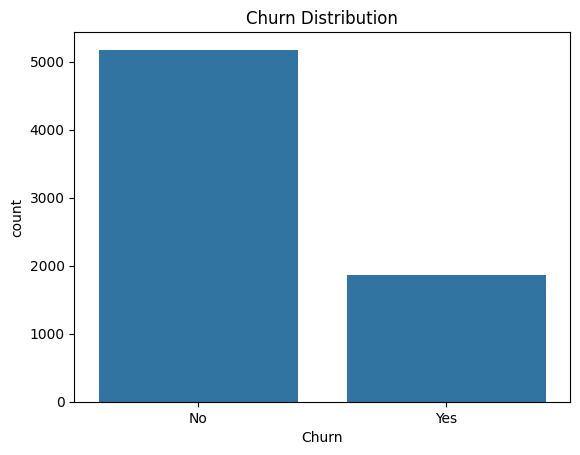

In [11]:
sns.countplot(x='Churn', data = dt)
plt.title('Churn Distribution')
plt.show()

The distribution of Churn values is shown which clearly shows that there is a higher percentage of churn rate for this organization.

- Imbalanced Dataset
- Most customers stay with company

GENDER VS. CHURN

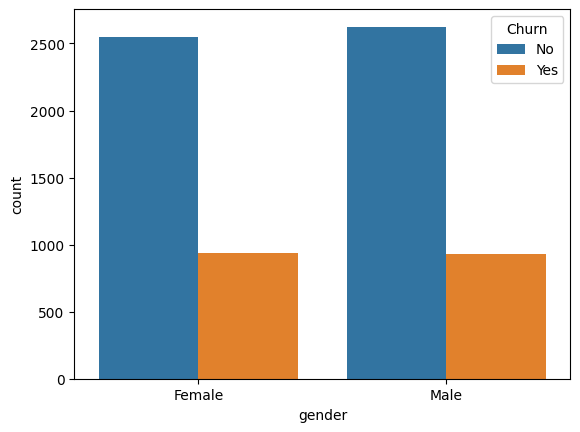

In [12]:
sns.countplot(x='gender', hue='Churn', data=dt)
plt.show()


This shows that churn in both the gender types is quite similar.
- Gender has no strong influence over customer churn

CONTRACT VS. CHURN

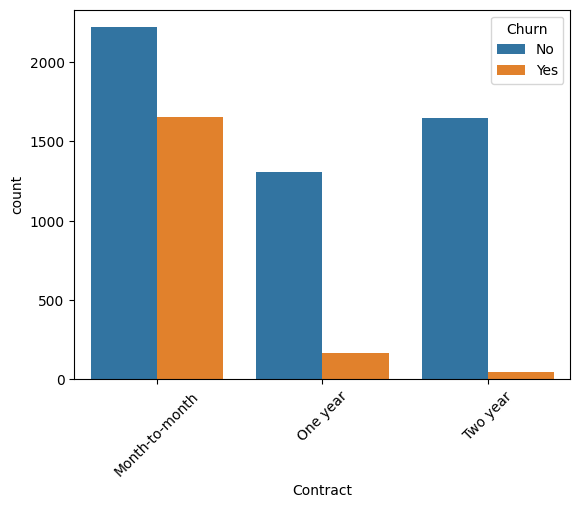

In [13]:
sns.countplot(x='Contract', hue='Churn', data=dt)
plt.xticks(rotation=45)
plt.show()

This shows that customers with Month-to-month contract type show great amount of churn as compared to one-year and two-year contract type.
- Long term contracts improve retention

MONTHLY CHARGES VS. CHURN

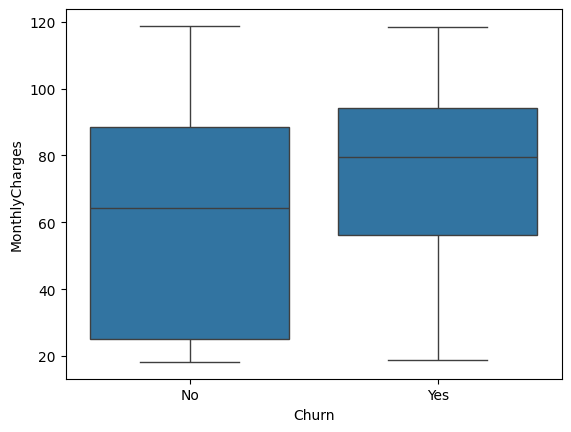

In [14]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=dt)
plt.show()

The comparision is quite evident. The boxplots clearly show that the customers who had churned had to pay higher monthly charges as compared to first box plot. The second plot clearly shows that the data is left skewed with bulk of data on the higher side of monthly charges.

- Higher costs may increase likelihood of churn.

SENIOR CITIZEN VS. CHURN

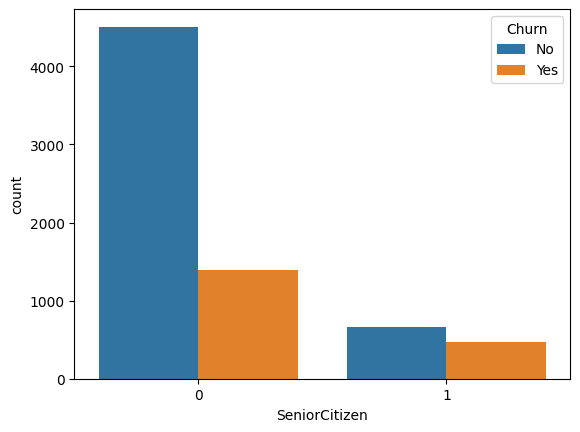

In [15]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=dt)
plt.show()

Customers who were not senior citizen show higher churn ratio as compared to those which fall under senior citizen category.

TENURE DISTRIBUTION

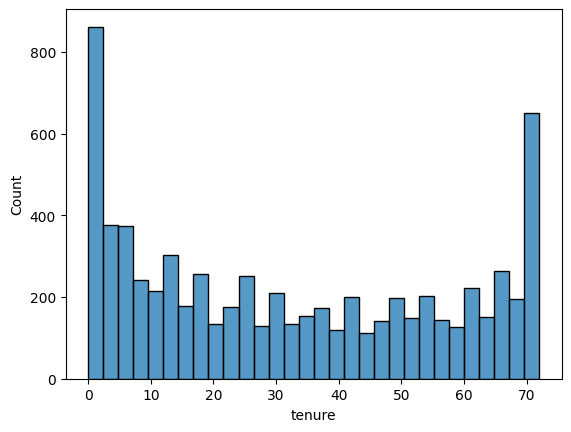

In [16]:
sns.histplot(dt['tenure'], bins=30)
plt.show()

Many customers are either very old or very new. The customer base contains both newly acquired and long-term loyal customers.

CORRELATION HEATMAP

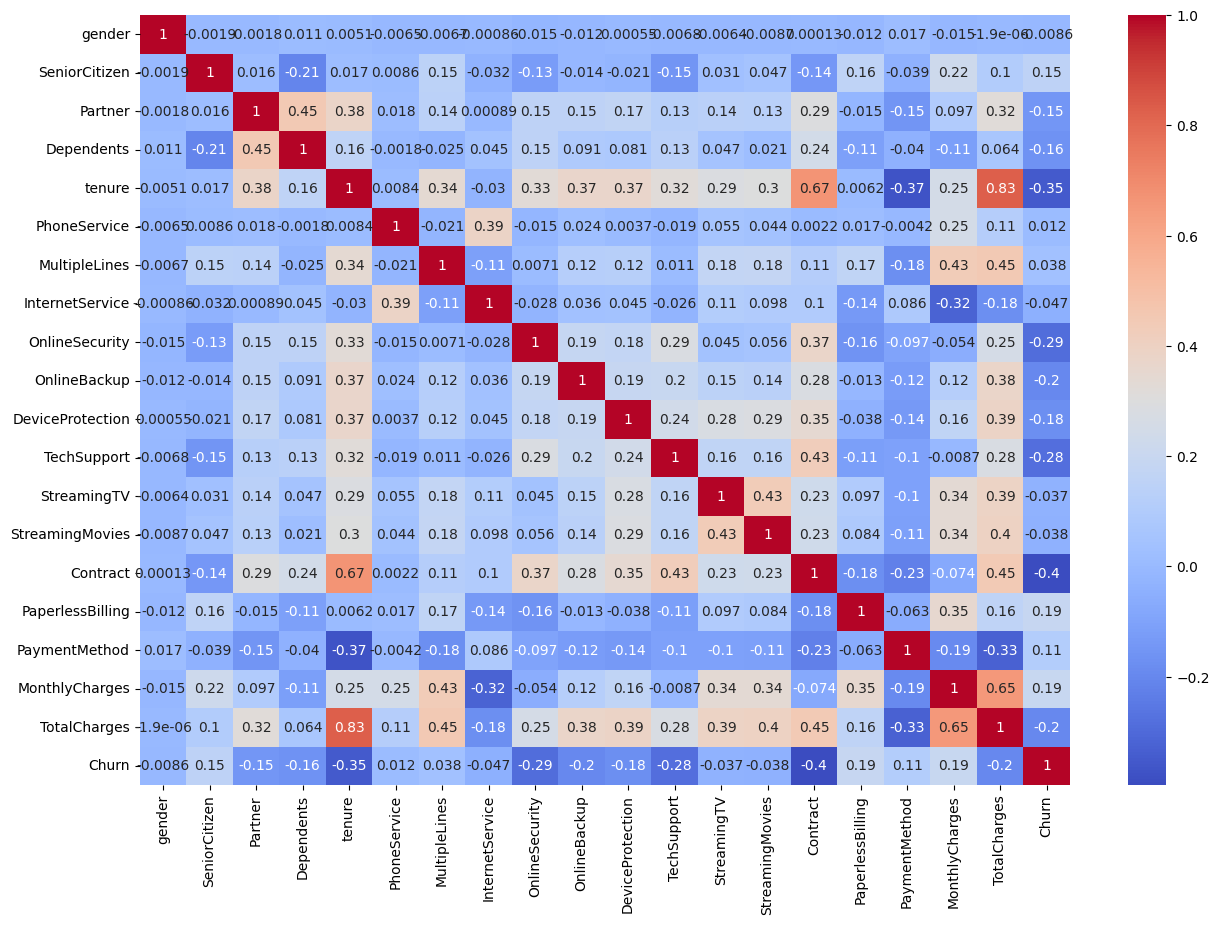

In [17]:
temp_dt = dt.copy()

le = LabelEncoder()

for col in temp_dt.columns:
  if temp_dt[col].dtype == 'object':
    temp_dt[col] = le.fit_transform(temp_dt[col])

plt.figure(figsize=(15,10))
sns.heatmap(temp_dt.corr(), cmap = "coolwarm", annot=True)
plt.show()

###6. Feature Engineering

In [18]:
dt['gender'] = dt['gender'].map({'Female': 0, 'Male': 1})

In [19]:
yes_no_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

for col in yes_no_cols:
    dt[col] = dt[col].map({'Yes': 1, 'No': 0})

In [20]:
internet_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in internet_cols:
    dt[col] = dt[col].replace(
        'No internet service',
        'No'
    )

    dt[col] = dt[col].map({'Yes': 1, 'No': 0})

In [21]:
dt['MultipleLines'] = dt['MultipleLines'].replace(
    'No phone service',
    'No'
)

dt['MultipleLines'] = dt['MultipleLines'].map({'Yes': 1, 'No': 0})

# ==========================================
# ONE-HOT ENCODE REMAINING CATEGORICALS
# ==========================================

categorical_cols = [
    'InternetService',
    'Contract',
    'PaymentMethod'
]

dt = pd.get_dummies(
    dt,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

# ==========================================
# FEATURES & TARGET
# ==========================================

X = dt.drop('Churn', axis=1)
y = dt['Churn']
print("Shape after encoding:", X.shape)
X.head()

Shape after encoding: (7043, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,1,0,0,0,0,1,0


In [22]:
y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [23]:
#==================
# TRAIN TEST SPLIT
#==================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Divides dataset into 80% traning data and 20% test data

###7. Model Training and Evaluation

1. LOGISTIC REGRESSION

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)



Evaluate Logistic Regression

In [25]:
print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

LOGISTIC REGRESSION
Accuracy: 0.8204400283889283

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409


Confusion Matrix:
[[934 102]
 [151 222]]


2. RANDOM FOREST CLASSIFIER

In [26]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

Evaluate Random Forest

In [27]:
#print("Accuracy:", accuracy_score(y_test, rf_pred))
#print(classification_report(y_test, rf_pred))
print("\n" + "="*50)
print("RANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))


RANDOM FOREST
Accuracy: 0.7913413768630234

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1036
           1       0.65      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
[[940  96]
 [198 175]]


**Logistic Regression is the better model.**

Why?
- Higher accuracy
- Higher recall
- Higher F1-score
- Better at detecting churners

Two classification models, Logistic Regression and Random Forest, were trained and evaluated. Logistic Regression achieved an accuracy of 82.0%, outperforming Random Forest's 79.1%. Additionally, Logistic Regression achieved higher recall (60%) for churn prediction compared to Random Forest (47%), making it more effective at identifying customers likely to leave the service. Therefore, Logistic Regression was selected as the preferred model for this project.

3. XGBOOST CLASSIFIER

In [28]:
from xgboost import XGBClassifier

In [29]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [30]:
xgb_pred = xgb_model.predict(X_test)

In [31]:
print("XGBOOST")
print("Accuracy:",
      accuracy_score(y_test, xgb_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    xgb_pred
))

XGBOOST
Accuracy: 0.8140525195173882

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.54      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409



In [32]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

print("Confusion Matrix:")

print(cm)

Confusion Matrix:
[[944  92]
 [170 203]]


**Out of all the three models trained here - Logistic Regression is very suitable for this Customer churn dataset**

In [33]:
#ROC-AUC Score for Logistic Regression model
lr_probs = lr.predict_proba(X_test_scaled)[:,1]

lr_auc = roc_auc_score(
    y_test,
    lr_probs
)

print("Logistic Regression ROC-AUC:", lr_auc)

Logistic Regression ROC-AUC: 0.8620118107383524


In [34]:
#ROC-AUC Score for Random Forest Classifier model
rf_probs = rf_model.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(
    y_test,
    rf_probs
)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.8402457896425726


In [35]:
#ROC-AUC Score for XGBoost Classifier model
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

xgb_auc = roc_auc_score(
    y_test,
    xgb_probs
)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.8610362085563159


###8. Saving Models

In [36]:
import joblib

joblib.dump(lr, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

['feature_columns.pkl']

###9. Business Insights

In [37]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient
15,TotalCharges,0.618895
16,InternetService_Fiber optic,0.597254
12,StreamingMovies,0.220249
11,StreamingTV,0.170182
13,PaperlessBilling,0.164054
6,MultipleLines,0.163907
21,PaymentMethod_Electronic check,0.152598
1,SeniorCitizen,0.058519
2,Partner,0.027475
9,DeviceProtection,0.023870


In [38]:
coef_df

,Feature,Coefficient
15,TotalCharges,0.618895
16,InternetService_Fiber optic,0.597254
12,StreamingMovies,0.220249
11,StreamingTV,0.170182
13,PaperlessBilling,0.164054
6,MultipleLines,0.163907
21,PaymentMethod_Electronic check,0.152598
1,SeniorCitizen,0.058519
2,Partner,0.027475
9,DeviceProtection,0.023870


**Key Findings from Your Model**

Top Factors Increasing Churn Risk

Feature	                   Coefficient

TotalCharges	              +0.619

InternetService_Fiber optic	+0.597

StreamingMovies	            +0.220

StreamingTV	                +0.170

PaperlessBilling	          +0.164

MultipleLines	               +0.164

PaymentMethod_Electronic check	+0.153

**Insight 1: Fiber Optic Customers Are More Likely to Churn**

Customers subscribed to Fiber Optic internet services show significantly higher churn risk.

**Business Action**:

1. Conduct customer satisfaction surveys for Fiber Optic users.
2. Investigate pricing, service quality, and support issues.
3. Offer loyalty incentives to high-value Fiber customers.

**Insight 2: Electronic Check Users Are Higher Risk**

Customers paying via Electronic Check have a higher tendency to churn.

**Business Action**:

1. Encourage migration to automatic payment methods.
2. Provide incentives for auto-pay enrollment.

**Insight 3: Customers Using Multiple Entertainment Services Show Higher Churn**

Streaming TV and Streaming Movies users demonstrate increased churn probability.

**Business Action**:

1. Create bundled entertainment packages.
2. Improve perceived value through exclusive content offers.

**Top Factors Reducing Churn**

Feature	         Coefficient

tenure	            -1.321

Contract_Two year	  -0.619

MonthlyCharges	     -0.562

InternetService_No  -0.504

Contract_One year	   -0.269

OnlineSecurity	     -0.163

TechSupport	         -0.125

**Insight 4: Tenure Is the Strongest Predictor**

The strongest retention factor is customer tenure.

Customers who stay longer are significantly less likely to churn.

**Business Action:**

1. Focus retention efforts during the first year.
2. Implement onboarding programs for new customers.
3. Launch loyalty rewards for long-term customers.

**Insight 5: Long-Term Contracts Dramatically Reduce Churn**

Both one-year and two-year contracts are associated with much lower churn risk.

The two-year contract is among the strongest retention drivers.

**Business Action:**

1. Promote annual and multi-year plans.
2. Offer discounts for contract upgrades.
3. Design retention campaigns around contract renewal periods.

**Insight 6: Security and Support Services Improve Retention**

Customers using Online Security and Tech Support are less likely to churn.

**Business Action:**

1. Bundle security and support services into standard plans.
2. Offer free trial periods to increase adoption.

###10. Conclusion

A customer churn prediction model was developed using the Telco Customer Churn dataset. Three machine learning algorithms were evaluated: Logistic Regression, Random Forest, and XGBoost.

Logistic Regression achieved the best overall performance with:

* Accuracy: 82.04%
* ROC-AUC: 0.8620
* Recall (Churn): 60%

Key findings indicate that customer tenure, contract type, internet service type, payment method, and value-added services are the primary drivers of churn behavior.

The analysis reveals that customers on Fiber Optic internet plans and those using Electronic Check payments are more likely to churn. Conversely, customers with longer tenure, long-term contracts, Online Security, and Tech Support services exhibit significantly lower churn rates.

Based on these findings, the company should prioritize early-stage customer retention programs, promote long-term contracts, encourage automatic payment methods, and increase adoption of security and support services to reduce customer attrition.

The final model can be integrated into customer relationship management systems to identify high-risk customers and trigger proactive retention strategies.
